In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
from equilibrium_critical_correlations import *

In [22]:
n = 4
r= 3
indices = [i for i in range(r,n+r)]
print(indices)

[3, 4, 5, 6]


In [35]:
#Typical Pn function
def z_P_n(n,r,even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i+int(r) for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []
   # print(terms)
    for term in terms:
        #print(term)
        indices = term
        #degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices))))
        else:
           # print(r,indices)
            val = z_xchain(0,indices)
            #print(val)
            dat.append(val)#*degen)
    #dat.append(z_xchain(r,[]))
    #All terms have equal weight. 
    return np.sum(dat)/2**n

In [36]:
rs =np.linspace(-50,50)

In [41]:
ns = [2, 4, 8, 12]
data = np.array([
    [z_P_n(n, -r) - ex.P_n(n) * ez.sigma_general([0]) for r in rs]
    for n in ns
])




/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


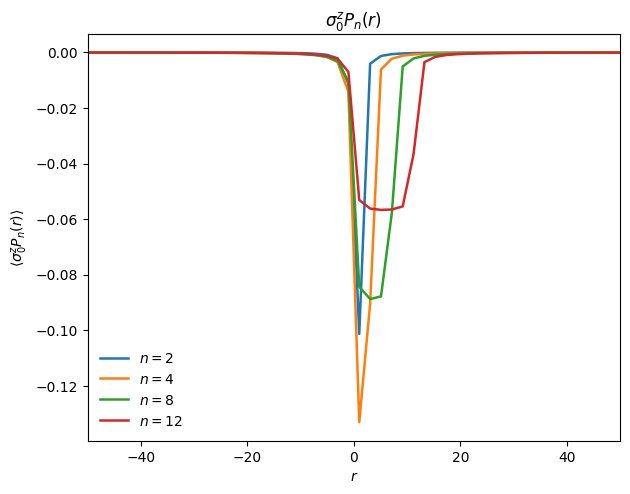

In [56]:
for i, n in enumerate(ns):
    plt.plot(rs, data[i], label=fr"$n={n}$", lw=1.8)

plt.xlim(-50, 50)
plt.xlabel(r"$r$")
plt.ylabel(r"$\langle \sigma^z_0 P_n(r)\rangle$")
plt.legend(frameon=False)
plt.tight_layout()
title(r"$\sigma^z_0 P_n(r)$")
plt.show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


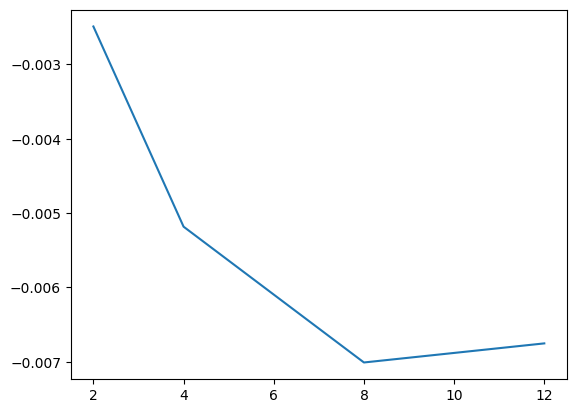

In [55]:
sums =[]
for i, n in enumerate(ns):
    sums.append(sum(data[i])/len(rs)) 

plot(ns,sums)

In [43]:
from numpy.fft import fft, fftfreq, fftshift

k = fftshift(fftfreq(len(rs), 1)) * 2 * pi
data_fft = np.array([fftshift(fft(row)) for row in data])


Text(0.5, 1.0, 'Normalized FT($\\sigma^z_0 P(r)$)')

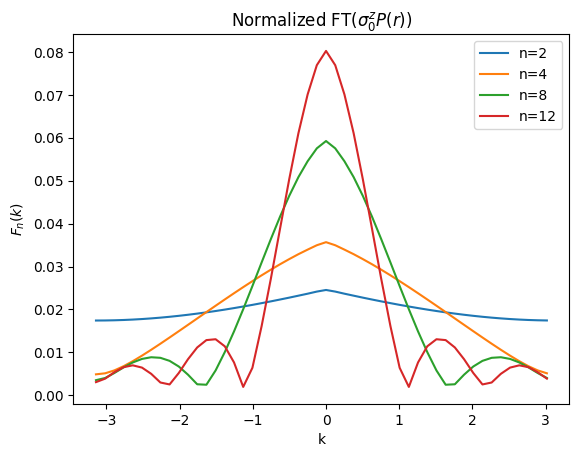

In [50]:
for i,dat in enumerate(data_fft):
    plot(k,abs(dat)/sum(abs(dat)),label=f"n={ns[i]}")
legend()

xlabel("k")
ylabel(r"$F_n(k)$")
title(r"Normalized FT($\sigma^z_0 P(r)$)")

# I want to turn sigma_General into a new function 

In [4]:

def z_sigma_x(z_index,x_indices):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    x_indices = np.sort(x_indices)
    #Remove any duplicates as sigma_x^2 = 1
    x_indices = remove_duplicates_in_pairs(x_indices)
    #Bs sit on odd sites
    odd_sites = np.array(x_indices[::2])
    #As site on even sites
    even_sites= np.array(x_indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = Dn(Nd)
    return np.linalg.det(C)



In [5]:
def z_xchain(r,x_indices):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    x_indices = np.sort(x_indices)
    #Remove any duplicates as sigma_x^2 = 1
    x_indices = remove_duplicates_in_pairs(x_indices)
    #Bs sit on odd sites
    odd_sites = np.array(x_indices[::2])
    #As site on even sites
    even_sites= np.array(x_indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths+1)
    #Fill in indices for strings
    R = []
    for i in range(0, len(x_indices), 2):
        start = x_indices[i]
        end = x_indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [r]+[x for x in R if x not in odd_sites]
    B_coords = [r]+[x for x in R if x not in even_sites]
    N =len(A_coords)
    C = np.zeros((N,N),dtype=complex)
    #print(N)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = Dn(Nd)
    return -np.linalg.det(C)


In [334]:
z_xchain(0,[])

1


np.complex128(0.6366197723675814-0j)

In [390]:

x=[]
for r in rs:
    A_coords = [0,r+1]
    B_coords = [0,r]
    A_coords = [0,r+1,r+3]
    B_coords = [0,r,r+2]
    N = len(A_coords)
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = Dn(Nd)
    val = np.linalg.det(C)
    x.append(-val)
x=array(x)
print(x)

[ 0.27519891-0.j  0.27519765-0.j  0.27519623-0.j  0.27519459-0.j
  0.27519271-0.j  0.27519052-0.j  0.27518796-0.j  0.27518494-0.j
  0.27518134-0.j  0.275177  -0.j  0.2751717 -0.j  0.27516515-0.j
  0.27515691-0.j  0.27514635-0.j  0.27513251-0.j  0.27511385-0.j
  0.27508788-0.j  0.27505018-0.j  0.27499245-0.j  0.27489748-0.j
  0.27472451-0.j  0.27435638-0.j  0.27332631-0.j  0.26783476-0.j
 -0.04572021-0.j  0.26134775-0.j  0.27272411-0.j  0.27418722-0.j
  0.27465446-0.j  0.27486192-0.j  0.27497197-0.j  0.27503732-0.j
  0.27507928-0.j  0.27510782-0.j  0.27512811-0.j  0.27514305-0.j
  0.27515437-0.j  0.27516316-0.j  0.2751701 -0.j  0.2751757 -0.j
  0.27518027-0.j  0.27518404-0.j  0.27518721-0.j  0.27518988-0.j
  0.27519216-0.j  0.27519412-0.j  0.27519581-0.j  0.27519729-0.j
  0.27519859-0.j  0.27519973-0.j]


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


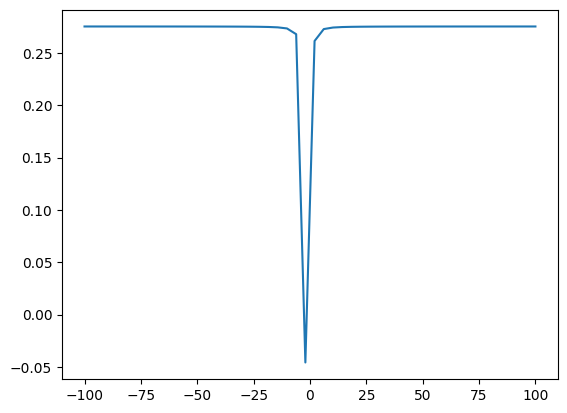

In [391]:
plot(rs,x)

In [7]:
import equilibrium_z_projectors as ez
import equilibrium_critical_correlations as ex

norm = ez.sigma_general([0])*ex.sigma_general([0,1])
print(norm)


(0.40528473456935116+0j)


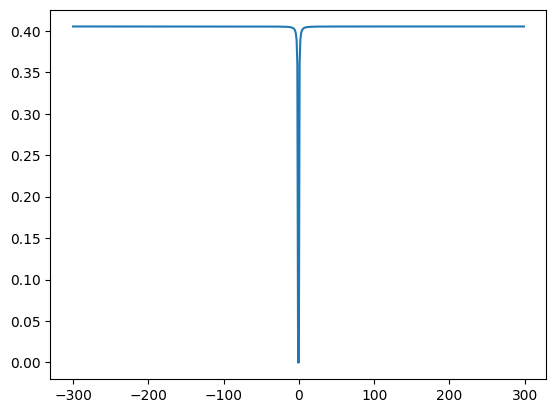

In [288]:
plot(rs,(x))
#plot(rs,rs**(-2.))
#loglog()

In [268]:
    A_coords = [1,2,4]
    B_coords = [1,1,3]
    N = len(A_coords)
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = Dn(Nd)
    val = np.linalg.det(C)

In [227]:
val

np.complex128(-4.919523786071357e-17+0j)

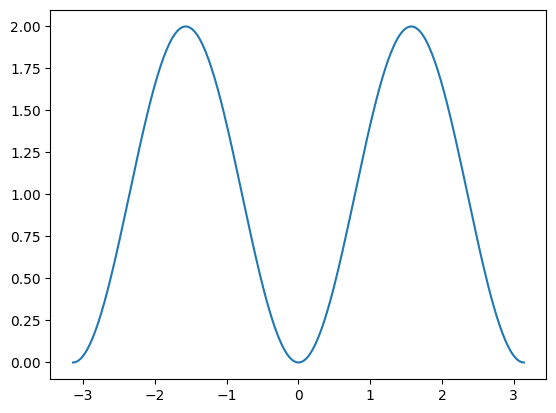

In [24]:
k = np.linspace(-pi,pi,300)
def theta_k(g):
    return np.atan2(sin(k),g-cos(k))
g=1000
plot(k,1-cos(k)**2+sin(k-theta_k(g))**2)
